# Choosing the demand model for the Citi Bike digital twin

The project is a platform for flow-graph problems: networks where commodities move
between facilities. One domain is implemented end to end so far — the Citi Bike
bike-sharing system in New York City — and the platform is built so that more domains
can be added later. For Citi Bike the platform runs two canonical scenarios: a
**base replay** that re-runs a historical month exactly as it happened
([`test_pipeline.ipynb`](test_pipeline.ipynb)), and a **forecast run** where the same
simulator runs on predicted demand instead of history
([`forecast_pipeline.ipynb`](forecast_pipeline.ipynb)).

The forecast run needs a demand model. This notebook is the research story behind that
model: what is being forecast, what the data looks like, which model families were
compared, and how the winner was picked.

One idea is worth stating up front: **a forecast is judged twice**. Level 1 scores it
as a forecast — error against a held-out month. Level 2 feeds it into the simulator and
scores the run it produces against the run on actual demand. The platform consumes
forecasts through the simulator, and it turns out (section 6) that the model with the
best forecast error is not the model that produces the most faithful operations.

How to read and run this notebook:

- Every computation calls existing `gbp` code; no logic is re-implemented in cells.
- `RUN_HEAVY = False` (the default) computes the light parts live and reads the heavy
  parts — the model backtest and the simulator runs — from their saved results (the
  MLflow store and `data/ml/evaluation/`). With `RUN_HEAVY = True` the same cells
  recompute everything; that takes hours.
- Data on disk: months 2025-02 … 2026-02 of Citi Bike trips, prepared into monthly
  training partitions by `python -m gbp.ml.training`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gbp.ml.training import load_actual_month, partition_path

# mlflow imports tqdm, which warns when notebook widgets are not installed.
warnings.filterwarnings("ignore", module="tqdm")

RUN_HEAVY = False  # True: re-run the backtest and the simulator runs (hours).

MONTHS = list(pd.period_range("2025-02", "2026-02", freq="M").strftime("%Y%m"))
EVAL_MONTH = "202601"  # the held-out month of the final comparison

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "font.size": 10,
        "legend.frameon": False,
    }
)

# The palette of the Streamlit app (app/ui_shared.py); one fixed color per model family.
MODEL_COLORS = {
    "seasonal_naive": "#898781",
    "sarimax": "#eda100",
    "lightgbm": "#2a78d6",
    "graphsage": "#4a3aa7",
}
ACCENT = "#1baf7a"  # single-series plots
DARK = "#33322e"  # the actual / reference series

## 1. Problem statement

**What is forecast.** One number per station, hour, and bike type: how many riders
will want to depart from this station during this hour on a classic or an electric
bike. In the project's vocabulary a station is a *facility*, a bike type is a
*commodity category*, an hour is a *period*, and a demand table is a table with the
columns `period_id, facility_id, commodity_category, quantity`.

**Why.** The simulator moves bikes between roughly 2,200 stations period by period.
The base replay takes its demand table from history; the forecast run takes it from a
model. That is the only difference between the two runs, so the whole forecasting
problem is: produce one table of exactly this shape for future periods.

**How success is measured.** Two levels:

1. *Forecast error* on a held-out month — mean absolute error (MAE) and Poisson
   deviance per station-hour row (`gbp/ml/metrics.py`).
2. *Operational closeness* — run the simulator on the forecast and compare the run's
   totals (departed trips, lost demand, redirected arrivals, rebalancing cost) against
   the reference run on actual demand. Closeness to the reference is the target, not
   low cost: an under-forecast makes the simulated system look "cheap" simply because
   trips never happen in it.

In [2]:
demand = load_actual_month(EVAL_MONTH)
print(
    f"{EVAL_MONTH}: {len(demand):,} rows, "
    f"{demand['facility_id'].nunique():,} stations, "
    f"{demand['quantity'].sum():,} departures, "
    f"{(demand['quantity'] == 0).mean():.0%} of rows are zero"
)
demand.head()

202601: 3,483,408 rows, 2,341 stations, 1,845,547 departures, 77% of rows are zero


,period_id,facility_id,commodity_category,quantity
0,0,1234.56,classic_bike,0
1,0,1234.56,electric_bike,0
2,0,1964.01,classic_bike,0
3,0,1964.01,electric_bike,0
4,0,2009.04,classic_bike,0


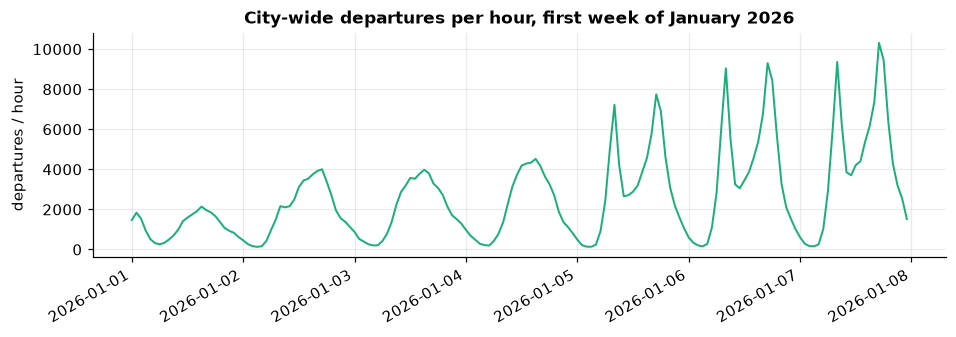

In [3]:
jan_hourly = (
    pd.read_parquet(partition_path(EVAL_MONTH), columns=["start_timestamp", "quantity"])
    .groupby("start_timestamp", as_index=False)["quantity"]
    .sum()
)
week = jan_hourly[
    jan_hourly["start_timestamp"] < jan_hourly["start_timestamp"].min() + pd.Timedelta(weeks=1)
]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(week["start_timestamp"], week["quantity"], color=ACCENT, lw=1.3)
ax.set_title("City-wide departures per hour, first week of January 2026")
ax.set_ylabel("departures / hour")
fig.autofmt_xdate()
plt.show()

This is the target signal at city scale: two sharp weekday peaks (morning and evening
commute) and a flatter weekend shape. The model has to reproduce this pattern *per
station and bike type*, where the counts are small — as the print above shows, most
station-hour rows are zero. That imbalance will matter later, when we look at what MAE
does and does not reward.

## 2. Exploratory analysis

The training partitions (`data/ml/training/<YYYYMM>.parquet`, one file per month, built
by `python -m gbp.ml.training`) hold one row per station-hour and bike type: the
departure count plus the feature columns. Each partition has about three million rows,
so the cells below aggregate them month by month instead of loading everything at once.

In [4]:
city_hourly = []
station_totals = []
for month in MONTHS:
    part = pd.read_parquet(
        partition_path(month), columns=["start_timestamp", "facility_id", "quantity"]
    )
    city_hourly.append(part.groupby("start_timestamp", as_index=False)["quantity"].sum())
    station_totals.append(
        part.groupby("facility_id", as_index=False)["quantity"].sum().assign(month=month)
    )
city_hourly = pd.concat(city_hourly, ignore_index=True).sort_values("start_timestamp")
station_totals = pd.concat(station_totals, ignore_index=True)
print(
    f"{len(city_hourly):,} hours, {station_totals['facility_id'].nunique():,} stations, "
    f"{city_hourly['quantity'].sum():,} departures over {len(MONTHS)} months"
)

9,432 hours, 2,460 stations, 47,527,080 departures over 13 months


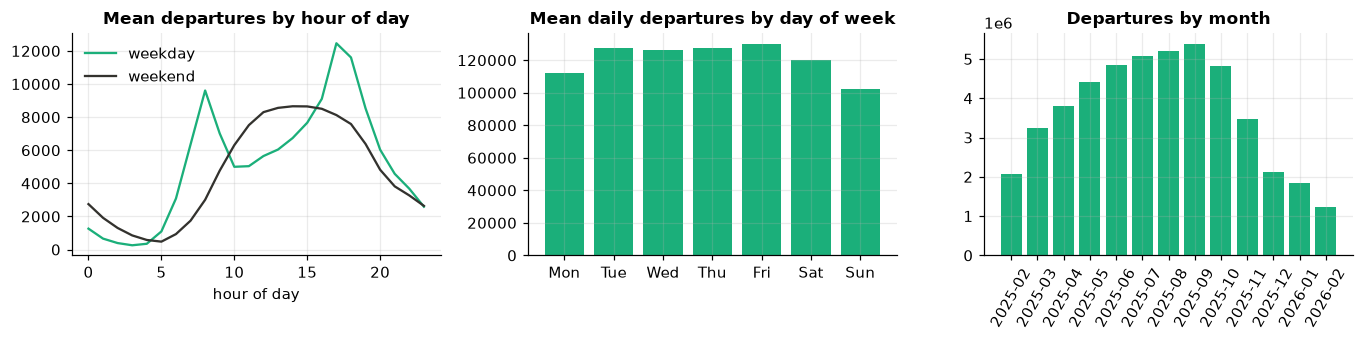

In [5]:
hours = city_hourly.assign(
    hour=city_hourly["start_timestamp"].dt.hour,
    weekend=city_hourly["start_timestamp"].dt.dayofweek >= 5,
)
daily = city_hourly.groupby(city_hourly["start_timestamp"].dt.normalize())["quantity"].sum()
monthly = city_hourly.groupby(city_hourly["start_timestamp"].dt.to_period("M"))["quantity"].sum()

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
for weekend, label, color in [(False, "weekday", ACCENT), (True, "weekend", DARK)]:
    profile = hours[hours["weekend"] == weekend].groupby("hour")["quantity"].mean()
    axes[0].plot(profile.index, profile.values, label=label, color=color)
axes[0].set_title("Mean departures by hour of day")
axes[0].set_xlabel("hour of day")
axes[0].legend()

by_dow = daily.groupby(daily.index.dayofweek).mean()
axes[1].bar(by_dow.index, by_dow.values, color=ACCENT)
axes[1].set_title("Mean daily departures by day of week")
axes[1].set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

axes[2].bar(range(len(monthly)), monthly.values, color=ACCENT)
axes[2].set_title("Departures by month")
axes[2].set_xticks(range(len(monthly)), [str(p) for p in monthly.index], rotation=60)
fig.tight_layout()
plt.show()

Three seasonal signals, all strong:

- **Hour of day** — weekdays have two commute peaks, weekends one broad afternoon
  bump. The two day types are different regimes, not one shifted curve.
- **Day of week** — midweek days carry more trips than weekends.
- **Month** — a large yearly cycle: warm months carry two to three times the winter
  volume.

All three become model features (`hour_of_day`, `day_of_week`, `month`), and the
hour-of-week combination (168 values) is the backbone of the baseline model.

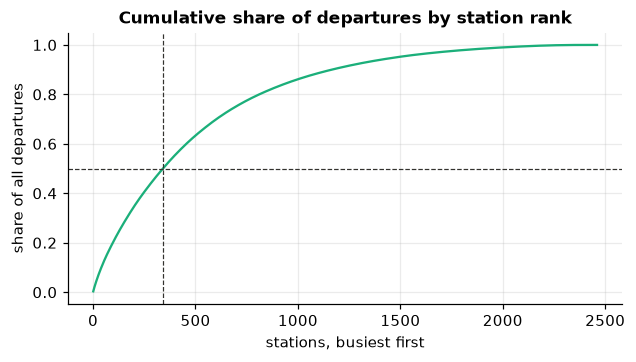

341 of 2460 stations produce half of all departures


In [6]:
from gbp.ml.metrics import busy_facility_ids

totals = station_totals.groupby("facility_id")["quantity"].sum().sort_values(ascending=False)
busy = busy_facility_ids(station_totals)
share = totals.cumsum() / totals.sum()

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(np.arange(1, len(share) + 1), share.values, color=ACCENT)
ax.axhline(0.5, color=DARK, lw=0.8, ls="--")
ax.axvline(len(busy), color=DARK, lw=0.8, ls="--")
ax.set_title("Cumulative share of departures by station rank")
ax.set_xlabel("stations, busiest first")
ax.set_ylabel("share of all departures")
plt.show()
print(f"{len(busy)} of {len(totals)} stations produce half of all departures")

Demand is heavily concentrated: a small fraction of the stations produces half of all
trips. This is why `gbp/ml/metrics.py` reports every error metric twice — for the
**busy** stations (the smallest set that produces half of the departures) and for the
quiet rest. A model can score a good overall MAE by predicting near-zero everywhere on
the long quiet tail; the busy split exposes that.

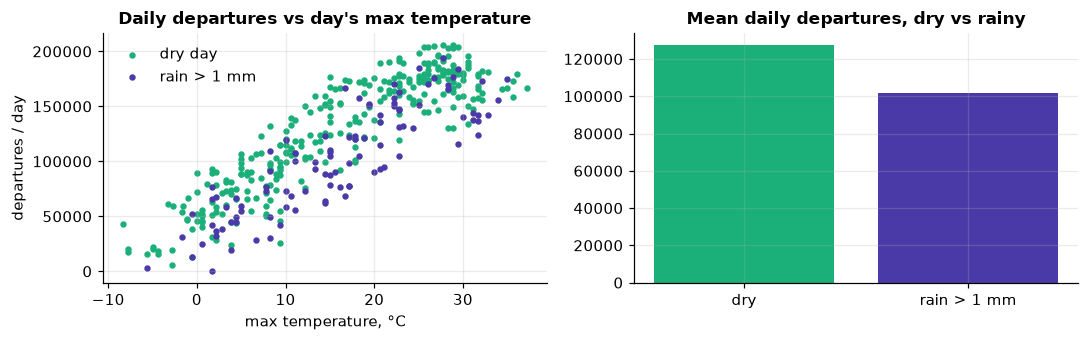

rainy days carry -20% departures vs dry days


In [7]:
from gbp.ml.data import load_weather_daily

weather = load_weather_daily(daily.index.min(), daily.index.max())
wx = weather.set_index("date").join(daily.rename("departures"), how="inner")
wet = wx["precipitation_mm"] > 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].scatter(
    wx.loc[~wet, "temperature_max_c"], wx.loc[~wet, "departures"],
    s=10, color=ACCENT, label="dry day",
)
axes[0].scatter(
    wx.loc[wet, "temperature_max_c"], wx.loc[wet, "departures"],
    s=10, color=MODEL_COLORS["graphsage"], label="rain > 1 mm",
)
axes[0].set_title("Daily departures vs day's max temperature")
axes[0].set_xlabel("max temperature, °C")
axes[0].set_ylabel("departures / day")
axes[0].legend()

means = [wx.loc[~wet, "departures"].mean(), wx.loc[wet, "departures"].mean()]
axes[1].bar(["dry", "rain > 1 mm"], means, color=[ACCENT, MODEL_COLORS["graphsage"]])
axes[1].set_title("Mean daily departures, dry vs rainy")
fig.tight_layout()
plt.show()
print(f"rainy days carry {means[1] / means[0] - 1:+.0%} departures vs dry days")

Temperature is the strongest day-level driver, and rain suppresses ridership on top of
it. Daily weather (max and min temperature, precipitation, from the NOAA Central Park
station) therefore enters the feature set. A caveat for honesty: the models are trained
and evaluated on *observed* weather; a production forecast would have to use a weather
forecast, which is less accurate. This is listed in the limitations at the end.

## 3. Censored demand

The training target is *observed departures*, and observation has a flaw: when a
station holds zero bikes, nobody can depart from it, so the recorded count is zero no
matter how many riders wanted a bike. Statistically the demand is **censored** — at
those hours the record is a lower bound of the true demand, not the value itself. A
model trained on the raw counts learns "demand at this station at this hour is zero",
which is exactly wrong: those are often the hours of *highest* demand, which is why the
station ran empty.

The public station-status feed (snapshots of every station's bike count, saved
monthly) shows when this happened. `gbp/ml/station_status.py` turns the snapshots into
one number per station-hour, **`stockout_share`** — the fraction of the hour the
station stood with zero bikes — and the training-table builder joins it onto every row.
Rows not covered by the feed keep `stockout_share = NaN`: "not observed", never "zero".

In [8]:
jan = pd.read_parquet(
    partition_path(EVAL_MONTH),
    columns=[
        "start_timestamp", "facility_id", "quantity",
        "stockout_share", "facility_hour_of_week_mean",
    ],
)
covered = jan[jan["stockout_share"].notna()]
print(
    f"{EVAL_MONTH}: stockout mark on {jan['stockout_share'].notna().mean():.0%} of rows; "
    f"{(covered['stockout_share'] > 0).mean():.1%} of covered rows touch a stockout; "
    f"{(covered['stockout_share'] >= 0.95).sum():,} rows spent (almost) the whole hour empty"
)

202601: stockout mark on 100% of rows; 8.8% of covered rows touch a stockout; 182,014 rows spent (almost) the whole hour empty


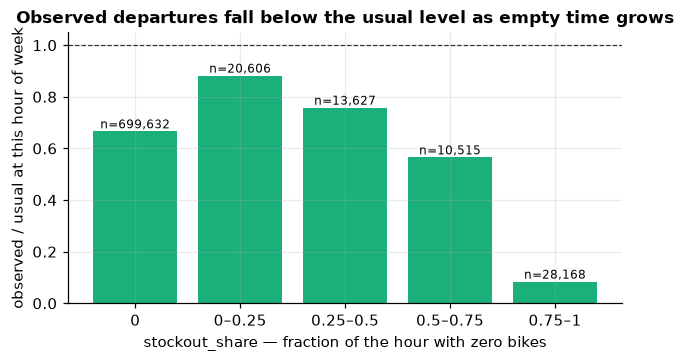

In [9]:
usual = covered[covered["facility_hour_of_week_mean"] >= 1].copy()
usual["ratio"] = usual["quantity"] / usual["facility_hour_of_week_mean"]
usual["bin"] = pd.cut(
    usual["stockout_share"],
    [-0.001, 0.001, 0.25, 0.5, 0.75, 1.0],
    labels=["0", "0–0.25", "0.25–0.5", "0.5–0.75", "0.75–1"],
)
by_bin = usual.groupby("bin", observed=True)["ratio"].agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.bar(by_bin.index.astype(str), by_bin["mean"], color=ACCENT)
ax.axhline(1.0, color=DARK, lw=0.8, ls="--")
ax.set_title("Observed departures fall below the usual level as empty time grows")
ax.set_xlabel("stockout_share — fraction of the hour with zero bikes")
ax.set_ylabel("observed / usual at this hour of week")
for x, (mean, size) in enumerate(by_bin.itertuples(index=False)):
    ax.annotate(f"n={size:,}", (x, mean), ha="center", va="bottom", fontsize=8)
plt.show()

This is the censoring made visible. For every covered station-hour with a meaningful
history (`facility_hour_of_week_mean ≥ 1`) the bar shows observed departures divided by
the station's usual count at that hour of week. Hours with no stockout sit near 1 — the
station performs as usual. The longer the station stood empty, the further the observed
count collapses below its usual level. The riders did not disappear; the bikes did.

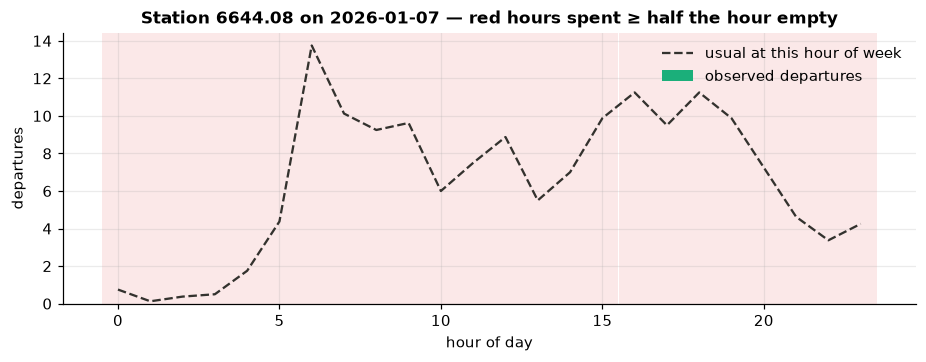

In [10]:
per_hour = covered.groupby(["facility_id", "start_timestamp"], as_index=False).agg(
    quantity=("quantity", "sum"),
    usual=("facility_hour_of_week_mean", "sum"),
    stockout_share=("stockout_share", "first"),
)
stockouts = per_hour[(per_hour["stockout_share"] >= 0.95) & (per_hour["usual"] >= 4)]
station = stockouts.groupby("facility_id").size().idxmax()
at_station = per_hour[per_hour["facility_id"] == station]
day = stockouts.loc[stockouts["facility_id"] == station, "start_timestamp"].dt.normalize().mode()[0]
one_day = at_station[at_station["start_timestamp"].dt.normalize() == day]

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(
    one_day["start_timestamp"].dt.hour, one_day["quantity"],
    color=ACCENT, label="observed departures",
)
ax.plot(
    one_day["start_timestamp"].dt.hour, one_day["usual"],
    color=DARK, ls="--", label="usual at this hour of week",
)
for hour in one_day.loc[one_day["stockout_share"] >= 0.5, "start_timestamp"].dt.hour:
    ax.axvspan(hour - 0.5, hour + 0.5, color="#e34948", alpha=0.12, lw=0)
ax.set_title(f"Station {station} on {day.date()} — red hours spent ≥ half the hour empty")
ax.set_xlabel("hour of day")
ax.set_ylabel("departures")
ax.legend()
plt.show()

A concrete day at the station with the most fully-empty busy hours: during the red
hours the recorded departures drop to zero while the dashed line says the station
usually serves several riders at that time.

**The correction.** The trainable models use the mark as a row weight: `LightGbmModel`
and `GraphSageModel` weight every training row by `1 − stockout_share`, so an hour the
station spent empty teaches the model almost nothing — instead of teaching it that
demand there is zero. The mark is a weight, not an imputation: no synthetic demand is
invented, and rows without feed coverage keep their full weight. This is deliberately
conservative; censoring-aware objectives are in the "what next" list at the end.

## 4. Feature engineering

`gbp/ml/features.py` is one builder used for both the training table and the forecast
input, so the two cannot drift apart. Three groups of features:

- **Calendar** — `hour_of_day`, `day_of_week`, `month`, `is_holiday` (US public
  holidays). Computed from the timestamp alone, so they are exactly known for any
  future period.
- **Weather** — `temperature_max_c`, `temperature_min_c`, `precipitation_mm`: daily
  values joined onto every hour of the day.
- **History** — computed from the departure counts of the 8 weeks before the target
  rows: the count at the same hour one week earlier (`quantity_lag_1w`), its mean over
  the last 4 weeks (`quantity_mean_4w`), the station's overall mean (`facility_mean`),
  and the station's mean at this hour of week (`facility_hour_of_week_mean`).

Leakage is excluded by construction, not by discipline: `build_features` raises an
error unless the newest history row is strictly before the first target row, and clips
the history to the 8-week window. A missing history or weather value stays `NaN` —
"not observed" is never turned into a zero.

In [11]:
from gbp.ml.features import FEATURE_COLUMNS

top_station = totals.index[0]
sample = pd.read_parquet(
    partition_path(EVAL_MONTH), filters=[("facility_id", "==", top_station)]
)
print(f"the busiest station: {top_station}")
sample[sample["hour_of_day"] == 8][
    ["start_timestamp", "commodity_category", "quantity", *FEATURE_COLUMNS]
].head(4)

the busiest station: 6140.05


,start_timestamp,commodity_category,quantity,hour_of_day,day_of_week,month,is_holiday,temperature_max_c,temperature_min_c,precipitation_mm,quantity_lag_1w,quantity_mean_4w,facility_mean,facility_hour_of_week_mean
16,2026-01-01 08:00:00,classic_bike,1,8,3,1,True,2.2,-5.6,0.5,0.0,6.25,4.606399,7.50
17,2026-01-01 08:00:00,electric_bike,0,8,3,1,True,2.2,-5.6,0.5,0.0,12.75,9.112351,17.25
64,2026-01-02 08:00:00,classic_bike,4,8,4,1,False,-1.1,-6.7,0.0,4.0,5.75,4.606399,7.00
65,2026-01-02 08:00:00,electric_bike,5,8,4,1,False,-1.1,-6.7,0.0,3.0,9.50,9.112351,13.00


## 5. Model families and the backtest

Four model families sit behind one `DemandModel` interface (`fit` on the training
table, `predict` on a feature table — `gbp/ml/models/`). They were picked to go from
simple to complex, so every step up in complexity has to justify itself against the
step below:

1. **`seasonal_naive`** — no fitting at all: predict the station's mean count at this
   hour of week over the last 8 weeks. The floor every other model must beat.
2. **`sarimax`** — a classical time-series model (SARIMAX with weekly seasonality) on
   a *single* series: the daily city total. The total is then split into station-hours
   by the historical hour-of-week shares. Tests whether city-level dynamics plus a
   fixed spatial split is enough.
3. **`lightgbm`** — one gradient-boosting model over all stations at once, Poisson
   objective, station and bike type as categorical features.
4. **`graphsage`** — a graph neural network (GraphSAGE) over the station graph built
   from trips. Tests whether learned spatial structure adds anything over boosting.

**Backtest design** (`gbp/ml/backtest.py`): rolling-origin over the monthly
partitions. The last three months are each held out in turn; for a test month the
models train on *all* months strictly before it. Concretely: test months 2025-11,
2025-12, 2026-01. The forecast input for a held-out month is built from history
strictly before it — the same leakage guard as in section 4. Every family is scored on
the same splits with the same metrics, and every split × family run is logged to MLflow
(experiment `demand-backtest`) with its parameters, the data version (the git commit of
the DVC files), and the fitted model as an artifact.

In [12]:
import mlflow

from gbp.ml.backtest import comparison_table, run_backtest
from gbp.ml.models import MODEL_FAMILIES
from gbp.ml.registry import BACKTEST_EXPERIMENT, MlflowStore

TEST_MONTHS = ["202511", "202512", "202601"]

if RUN_HEAVY:
    run_backtest(MONTHS[: MONTHS.index(EVAL_MONTH) + 1], n_splits=3)

store = MlflowStore()
store.activate()
experiment = mlflow.get_experiment_by_name(BACKTEST_EXPERIMENT)
runs = mlflow.search_runs([experiment.experiment_id])
split_runs = (
    runs[runs["params.model"].isin(MODEL_FAMILIES) & runs["params.test_month"].isin(TEST_MONTHS)]
    .sort_values("start_time")
    # The oldest run per model and month belongs to the four-family session;
    # later sessions re-ran only two families. After a RUN_HEAVY re-run the
    # newest runs are the ones to read.
    .drop_duplicates(["params.model", "params.test_month"], keep="last" if RUN_HEAVY else "first")
)
backtest = split_runs[
    [
        "params.model", "params.test_month", "metrics.mae", "metrics.mae_busy",
        "metrics.poisson_deviance", "metrics.fit_predict_seconds",
    ]
].rename(columns=lambda c: c.split(".", 1)[1])
comparison_table(backtest.to_dict("records")).round(3)

,model,mae,mae_busy,poisson_deviance,fit_predict_seconds
0,seasonal_naive,0.766,2.212,1.440,2.360
1,sarimax,0.649,1.836,1.307,4.789
2,lightgbm,0.623,1.647,0.956,383.738
3,graphsage,0.651,1.774,1.273,71.349


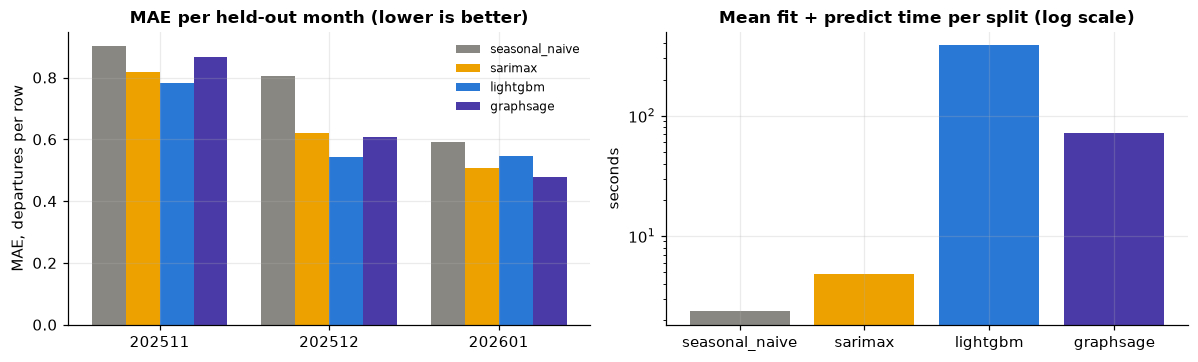

In [13]:
order = list(MODEL_FAMILIES)
by_month = backtest.pivot(index="test_month", columns="model", values="mae").sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
x = np.arange(len(by_month))
width = 0.2
for i, model in enumerate(order):
    axes[0].bar(
        x + (i - 1.5) * width, by_month[model], width, label=model, color=MODEL_COLORS[model]
    )
axes[0].set_xticks(x, by_month.index)
axes[0].set_title("MAE per held-out month (lower is better)")
axes[0].set_ylabel("MAE, departures per row")
axes[0].legend(fontsize=8)

seconds = backtest.groupby("model")["fit_predict_seconds"].mean().reindex(order)
axes[1].bar(order, seconds, color=[MODEL_COLORS[m] for m in order])
axes[1].set_yscale("log")
axes[1].set_title("Mean fit + predict time per split (log scale)")
axes[1].set_ylabel("seconds")
fig.tight_layout()
plt.show()

What the backtest says, averaged over the three splits:

- **LightGBM is first on every metric**: MAE ≈ 0.62 (naive floor 0.77), busy-station
  MAE ≈ 1.65, Poisson deviance ≈ 0.96.
- **GraphSAGE looks competitive on overall MAE** (≈ 0.65, and on the last split it is
  even the best: 0.478 vs LightGBM's 0.546). But recall from section 1 that most rows
  of the dense station-hour grid are zero: on this grid, with fractional predictions
  allowed, MAE rewards predicting near-zero everywhere. The metrics built to resist
  that — busy-station MAE and Poisson deviance — put GraphSAGE clearly behind
  LightGBM. This is a first warning, and section 6 turns it into a verdict.
- **SARIMAX beats the naive floor** on MAE but not on busy stations in a convincing
  way — a single city-wide series with fixed spatial shares has no way to react to
  station-level change.
- **Cost of complexity is real but affordable**: seconds for the naive and SARIMAX,
  about a minute for GraphSAGE, a few minutes for LightGBM per split, on a laptop.

A fair question at this point: *why not stop here and ship the best-MAE model?*
Because the platform does not consume MAE — it consumes simulator runs.

## 6. Two-level evaluation: forecast error vs operational cost

This is the central experiment of the project. For the held-out month 2026-01
(`gbp/ml/evaluation.py`, first week — 168 hourly periods):

1. Build one **reference run**: the simulator on the *actual* demand table.
2. For each family, build its forecast for the same window, round it to whole bikes,
   cut it to the scenario's stations, and run the simulator on it — with the **same
   replay state** (initial bikes and dock capacity, sized once from historical
   demand). Only the demand table differs between runs.
3. Compare every forecast run to the reference on operational totals: departed trips,
   lost demand, redirected arrivals, rebalancing cost.

The level-1 numbers below differ from the backtest table above, and that is expected:
here forecasts are whole bikes on the scenario's stations over one week, scored on the
union of non-zero rows — the backtest scored fractional predictions on the full dense
grid. Same models, a harder and more honest grid.

In [14]:
from gbp.ml.evaluation import evaluate_month, evaluation_dir

if RUN_HEAVY:
    level2 = evaluate_month(EVAL_MONTH, list(MODEL_FAMILIES), n_periods=168)
else:
    level2 = pd.read_csv(evaluation_dir(EVAL_MONTH) / "comparison_168p.csv")

reference = level2[level2["run_kind"] == "reference"].iloc[0]
forecast_runs = level2[level2["run_kind"] == "forecast"].set_index("model").loc[order].reset_index()
forecast_runs["departed_vs_ref_pct"] = 100 * (forecast_runs["departed"] / reference["departed"] - 1)
forecast_runs["cost_vs_ref_pct"] = 100 * (forecast_runs["cost"] / reference["cost"] - 1)

print(
    f"reference run: {reference['departed']:,.0f} trips departed, "
    f"rebalancing cost {reference['cost']:,.0f}"
)
forecast_runs[
    [
        "model", "level1_mae", "level1_mae_busy", "demand", "departed",
        "departed_vs_ref_pct", "lost_demand", "redirected", "cost", "cost_vs_ref_pct",
    ]
].round(2)

reference run: 424,191 trips departed, rebalancing cost 301,003


,model,level1_mae,level1_mae_busy,demand,departed,departed_vs_ref_pct,lost_demand,redirected,cost,cost_vs_ref_pct
0,seasonal_naive,1.45,2.10,518108.0,475255.0,12.04,42853.0,30178.0,344691.0,14.51
1,sarimax,1.30,1.71,304018.0,284737.0,-32.88,19281.0,12636.0,208055.0,-30.88
2,lightgbm,1.25,1.72,501531.0,455043.0,7.27,46488.0,26911.0,331415.0,10.10
3,graphsage,1.91,2.56,235631.0,152482.0,-64.05,83149.0,10335.0,114252.0,-62.04


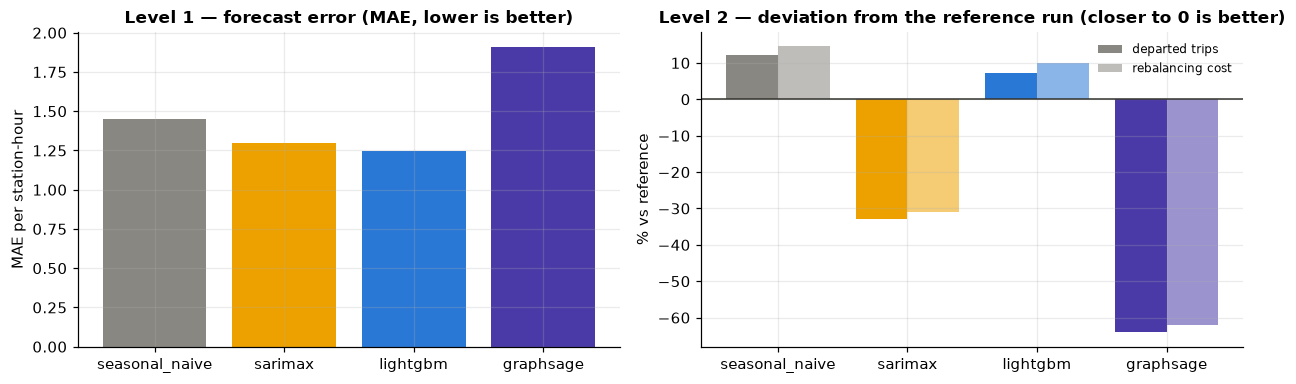

In [15]:
colors = [MODEL_COLORS[m] for m in order]
plot_df = forecast_runs.set_index("model").loc[order]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
axes[0].bar(order, plot_df["level1_mae"], color=colors)
axes[0].set_title("Level 1 — forecast error (MAE, lower is better)")
axes[0].set_ylabel("MAE per station-hour")

x = np.arange(len(order))
axes[1].bar(x - 0.2, plot_df["departed_vs_ref_pct"], 0.4, label="departed trips", color=colors)
axes[1].bar(
    x + 0.2, plot_df["cost_vs_ref_pct"], 0.4,
    label="rebalancing cost", color=colors, alpha=0.55,
)
axes[1].axhline(0, color=DARK, lw=1)
axes[1].set_xticks(x, order)
axes[1].set_title("Level 2 — deviation from the reference run (closer to 0 is better)")
axes[1].set_ylabel("% vs reference")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

The two levels disagree, and that disagreement is the headline result:

- **GraphSAGE**, near-best on backtest MAE, produces the *worst* run on the board:
  −64% departed trips, 83 thousand lost trips in one week, and the lowest rebalancing
  cost of all — "cheap" precisely because two thirds of the demand never happens in
  its world. Judged by raw cost it would win; judged by closeness to reality it loses
  completely.
- **SARIMAX vs the naive baseline** is a clean rank flip: SARIMAX wins level 1
  (MAE 1.30 vs 1.45) but loses level 2 badly (−33% departed vs +12%). It predicts the
  right monthly volume with the wrong within-month shape.
- **LightGBM** is the only model strong at both levels: best level-1 MAE and Poisson
  deviance *and* the smallest operational deviation (+7.3% departed, +10.1% cost). Its
  one systematic flaw is volume: it overpredicts the week by about 18%.

In one sentence: **forecast metrics alone would not have caught the difference between
a usable model and a catastrophic one; the simulator did.**

## 7. Champion choice and limitations

The winner is **LightGBM**: first on the honest level-1 metrics and closest to the
reference at level 2. The retraining pipeline (`python -m gbp.ml.pipeline`) registers
each newly trained model in the MLflow registry and moves the `champion` alias only if
the new version beats the current champion on the same backtest splits. The forecast
run resolves the model by that alias (`python -m gbp.ml.forecast --champion`), so the
choice made in this notebook is wired into the platform, not written down in a doc.

In [16]:
champion = MlflowStore().champion_version()
train_months = champion.tags["train_months"].split(",")
print(
    f"registry champion: {champion.tags['model_family']} — "
    f"version {champion.version} of 'demand-model', "
    f"trained on {train_months[0]}..{train_months[-1]} ({len(train_months)} months), "
    f"data version {champion.tags['data_version']}"
)

registry champion: lightgbm — version 2 of 'demand-model', trained on 202502..202602 (13 months), data version cdc8e2947df5-dirty


**Known limitations, stated proactively:**

- LightGBM overpredicts weekly volume by ~18–22%; a global calibration of totals
  (or a hierarchical reconciliation against a city-level model) is the obvious next
  step.
- Censored demand is down-weighted, not modeled; a censoring-aware objective
  (for example a Tobit-style likelihood, or an expectation-maximization loop that
  imputes demand during stockouts) could recover the lost signal instead of
  discarding it.
- The models see *observed* weather; a production system would consume a weather
  forecast with its own error.
- The stockout mark covers what the feed can see: about 99.7% of the rows. The few
  unmatched stations keep full training weight, censored or not.
- GraphSAGE underperforming is a result about *this* feature set and grain, not about
  graph models in general; a fair next attempt would give it the same calibration and
  more training months.
- The evaluation window is one week of one winter month; the full-month and
  warm-season evaluations run with the same command
  (`python -m gbp.ml.evaluation --month <YYYYMM>`).

**Where to go next in the repository:**

- The forecast run this notebook justifies: [`forecast_pipeline.ipynb`](forecast_pipeline.ipynb)
- The saved evaluation report: `docs/reports/model_evaluation_202601.md`
- The backtest, evaluation, and monitoring code: `gbp/ml/`
- Drift monitoring of saved forecasts: `python -m gbp.ml.monitoring --month <YYYYMM>`